# Comparing Performance of Different Exploration Methods

## 📚 Learning Objectives

By completing this notebook, you will:
- Compare different exploration strategies
- Evaluate exploration method performance
- Analyze exploration-exploitation trade-offs
- Visualize comparison results

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 2, lesson 01 "01. Cross-Validation for Model Evaluation" — one train/test split is not evidence, and neither is one training run; the same discipline of repeating and reporting spread is what makes a comparison of exploration strategies believable.

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 4**:
- Comparing performance of different exploration methods

---

## Introduction

Comparing exploration methods helps identify which strategies work best for different problems and understand the exploration-exploitation trade-off.

## Lesson Brief

This lesson compares multiple exploration methods side by side so students can see their behavior under the same conditions.

The main goal is to move beyond memorizing method names and instead observe practical trade-offs.

Why this matters: comparison notebooks help students build judgment about which method may fit a problem better.

Students should look for differences in speed, stability, and regret.

Teaching note: this notebook compares the methods inside one controlled **bandit-style simulation**. It is a useful comparison, but not an exhaustive statement about all RL environments.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: 25–30% more clicks, and the reason it was believable

Comparing exploration strategies is easy in a notebook and hard in production, because in production
you cannot run the alternative. Agarwal et al. built a system for exactly that problem — the
**Decision Service** ("Making Contextual Decisions with Low Technical Debt", 2016, a Microsoft
Research team including John Langford). It is a deployed contextual-bandit service, and the paper
reports **two live production deployments for content recommendation that achieved click-through
improvements of 25–30%**, plus another with an 18% revenue lift on a landing page.

The engineering that makes those numbers trustworthy is the part worth copying. The service logs the
*probability* with which each action was chosen, not just which action was chosen. With those
probabilities recorded you can, later and offline, get an unbiased estimate of how a *different*
policy would have performed on the same traffic — the replay method from lesson 01 of this unit,
which Li, Chu, Langford and Wang proved unbiased at WSDM 2011. Without logged probabilities, that
estimate is impossible and every future comparison becomes a new live experiment.

**What goes wrong without this.** A comparison table like the one below is only as good as its
protocol. If two strategies see different arms, different traffic or different seeds, the winner tells
you about the difference in conditions and nothing about the strategies. The table you are about to
print holds all of that constant — and, as the notebook itself says, it is still one seed.


## Recommended YouTube Video

To reinforce this lesson, watch **David Silver - "RL Course Lecture 9: Exploration and Exploitation"**:
[Watch on YouTube](https://www.youtube.com/watch?v=sGuiWX07sKw)

Why this pick:
- Useful when students are comparing strengths, weaknesses, and assumptions.
- Helps them interpret comparison plots with better theory in mind.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Exploration: trying uncertain actions.
- Exploitation: using the current best action.
- Regret: lost reward compared with always choosing the best arm.
- Convergence speed: how quickly a strategy settles near the best action.
- Stability: how noisy or reliable the learning curve looks.

### Quick Check
- Which method improves fastest in this simulation?
- Which method wastes less reward early on?
- Why should students compare regret, not only reward?
- Why does good performance in one bandit simulation not automatically generalize to every RL environment?

### Common Mistakes
- Assuming exploration means permanent randomness.
- Using one lucky run as proof.
- Confusing exploration rate with learning rate.
- Treating one comparison plot as a universal ranking for all RL problems.


## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


## How to Read Comparison Results Carefully

A comparison notebook is useful only if students know what conclusions are safe.

### Safe conclusions

From this notebook, students can say things like:

- one method found the best arm faster in this setup
- one method had lower regret in this setup
- one method looked more stable in this setup

### Unsafe conclusions

Students should **not** say:

- this method is always best for every RL problem
- this plot proves a universal ranking

### Why this warning matters

The current notebook is a controlled bandit-style comparison.
That is excellent for building intuition, but real RL environments add state transitions, delayed effects, and other complications.

So the correct habit is:

`compare carefully, then generalize cautiously.`

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Framework overview: name the strategies and metrics the comparison below really uses.
# Everything promised here is computed in the worked example — nothing stays on paper.

# Load the numeric and plotting libraries used by the comparison.
import numpy as np
import matplotlib.pyplot as plt

# Print the lesson banner.
print("✅ Libraries imported!")
print("\nComparing Exploration Methods Performance")
print("=" * 60)

# The four strategies the worked example trains head-to-head.
print("\nExploration Methods to Compare:")
print("  1. Epsilon-Greedy       (random with probability ε, else greedy)")
print("  2. Upper Confidence Bound (UCB — optimism bonus for rarely-tried arms)")
print("  3. Thompson Sampling    (sample beliefs, act on the sample)")
print("  4. Boltzmann Exploration (softmax over value estimates, taught in lesson 02)")

# The metrics the comparison actually computes and prints.
print("\nComparison Metrics (all computed below):")
print("  - Total reward over all rounds")
print("  - Cumulative regret (shortfall vs always playing the best arm)")
print("  - Best-arm share (fraction of pulls spent on the truly best arm)")
print("  - Convergence behaviour (read from the cumulative-average curves)")

print("\n✅ Comparison framework ready!")


✅ Libraries imported!

Comparing Exploration Methods Performance

Exploration Methods to Compare:
  1. Epsilon-Greedy       (random with probability ε, else greedy)
  2. Upper Confidence Bound (UCB — optimism bonus for rarely-tried arms)
  3. Thompson Sampling    (sample beliefs, act on the sample)
  4. Boltzmann Exploration (softmax over value estimates, taught in lesson 02)

Comparison Metrics (all computed below):
  - Total reward over all rounds
  - Cumulative regret (shortfall vs always playing the best arm)
  - Best-arm share (fraction of pulls spent on the truly best arm)
  - Convergence behaviour (read from the cumulative-average curves)

✅ Comparison framework ready!


## 🌍 Industry-Motivated Worked Example — A/B Testing with Multi-Armed Bandits

> **What is real here and what is not.** The industry uses below are real, and the
> stochastic reward is real in kind: each simulated visitor converts or does not, one draw at
> a time, exactly as in a live experiment. The underlying conversion rates are chosen by us
> and hidden from the algorithms — which is what lets us grade whether each method found the
> best variant. No company's traffic data is used.

**Industry context:**
- Netflix shows different thumbnails to different users and selects between them with bandit algorithms — the same family of method as below, at a very different scale
- Google Ads uses epsilon-greedy to balance showing ads that already work vs. testing new ones
- Booking.com runs 1000+ bandit experiments simultaneously

We compare **ε-greedy**, **UCB**, and **Thompson Sampling** on a **simulated** A/B test. The conversion rates are numbers we chose and then hid from the algorithms, so we can check afterwards whether each method actually found the best variant — something you can never verify on live traffic. The *randomness* is the real part: each visitor converts or does not, exactly as in a real experiment.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


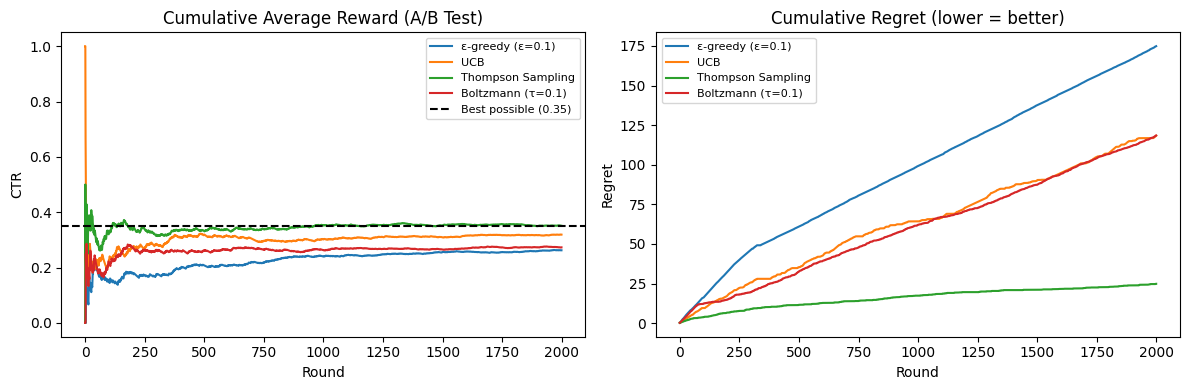

Strategy             | Total reward | Final regret | Best-arm share
--------------------------------------------------------------------
ε-greedy (ε=0.1)     |          525 |        174.9 |          2.5%
UCB                  |          638 |        118.3 |         46.9%
Thompson Sampling    |          702 |         24.8 |         89.9%
Boltzmann (τ=0.1)    |          546 |        118.5 |         55.2%

Highest total reward on THIS run: Thompson Sampling.
One seed is one sample — the ranking of close strategies can change on a rerun;
the regret curves and best-arm shares tell you WHY each strategy earned its total.


In [2]:
# Worked example: four exploration strategies on the SAME 5-variant A/B test.
# Each strategy returns its per-round rewards AND chosen arms, so every metric
# printed at the end is measured from this run — nothing is quoted from a textbook.

np.random.seed(42)

# ── Scenario: 5 website variants (like streaming-service thumbnails) ─────────
# True click-through rates are hidden from the agent; variant 2 is best (35%).
TRUE_RATES = [0.15, 0.22, 0.35, 0.18, 0.28]
N_ARMS = len(TRUE_RATES)
N_ROUNDS = 2000
BEST_ARM = int(np.argmax(TRUE_RATES))
BEST_RATE = max(TRUE_RATES)


def pull(arm):
    """One Bernoulli click with the arm's hidden rate."""
    return 1 if np.random.rand() < TRUE_RATES[arm] else 0


def epsilon_greedy(eps=0.1):
    """Classic ε-greedy: explore uniformly with probability ε, else exploit."""
    counts, totals = np.zeros(N_ARMS), np.zeros(N_ARMS)
    rewards, arms = [], []
    for _ in range(N_ROUNDS):
        # Coin flip decides explore vs exploit this round.
        arm = np.random.randint(N_ARMS) if np.random.rand() < eps \
            else int(np.argmax(totals / (counts + 1e-9)))
        r = pull(arm)
        counts[arm] += 1; totals[arm] += r
        rewards.append(r); arms.append(arm)
    return rewards, arms


def ucb(c=2.0):
    """UCB1: value estimate plus an optimism bonus that shrinks with visits."""
    counts, totals = np.zeros(N_ARMS), np.zeros(N_ARMS)
    rewards, arms = [], []
    for t in range(N_ROUNDS):
        if t < N_ARMS:
            # Play each arm once so every bonus term is defined.
            arm = t
        else:
            ucb_vals = totals / counts + np.sqrt(c * np.log(t + 1) / counts)
            arm = int(np.argmax(ucb_vals))
        r = pull(arm)
        counts[arm] += 1; totals[arm] += r
        rewards.append(r); arms.append(arm)
    return rewards, arms


def thompson():
    """Thompson Sampling with Beta(1,1) priors: sample beliefs, act on the sample."""
    alpha, beta_ = np.ones(N_ARMS), np.ones(N_ARMS)
    rewards, arms = [], []
    for _ in range(N_ROUNDS):
        # One belief sample per arm; play the arm whose sample looks best.
        arm = int(np.argmax(np.random.beta(alpha, beta_)))
        r = pull(arm)
        if r: alpha[arm] += 1
        else: beta_[arm] += 1
        rewards.append(r); arms.append(arm)
    return rewards, arms


def boltzmann(tau=0.1):
    """Boltzmann/softmax exploration (lesson 02): P(arm) ∝ exp(estimate / tau)."""
    counts, totals = np.zeros(N_ARMS), np.zeros(N_ARMS)
    rewards, arms = [], []
    for _ in range(N_ROUNDS):
        # Softmax over current running-mean estimates (max-subtracted for stability).
        q = totals / np.maximum(counts, 1)
        e = np.exp((q - q.max()) / tau)
        arm = int(np.random.choice(N_ARMS, p=e / e.sum()))
        r = pull(arm)
        counts[arm] += 1; totals[arm] += r
        rewards.append(r); arms.append(arm)
    return rewards, arms


# Run all four strategies on the same problem (shared RNG stream, fixed seed above).
strategies = {
    "ε-greedy (ε=0.1)": epsilon_greedy(0.1),
    "UCB": ucb(),
    "Thompson Sampling": thompson(),
    "Boltzmann (τ=0.1)": boltzmann(0.1),
}


def cumavg(lst):
    """Cumulative average — the convergence curve for one strategy."""
    return np.cumsum(lst) / np.arange(1, len(lst) + 1)


# ── Plots: convergence curves and cumulative regret ──────────────────────────
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for name, (rewards, _) in strategies.items():
    plt.plot(cumavg(rewards), label=name)
plt.axhline(BEST_RATE, color="k", linestyle="--", label=f"Best possible ({BEST_RATE})")
plt.title("Cumulative Average Reward (A/B Test)")
plt.xlabel("Round"); plt.ylabel("CTR"); plt.legend(fontsize=8)

plt.subplot(1, 2, 2)
for name, (_, arms) in strategies.items():
    # Pseudo-regret: expected shortfall of each CHOSEN arm vs the best arm.
    # (Built from the hidden true rates, so it is never negative by luck.)
    chosen_rates = np.array([TRUE_RATES[a] for a in arms])
    plt.plot(np.cumsum(BEST_RATE - chosen_rates), label=name)
plt.title("Cumulative Regret (lower = better)")
plt.xlabel("Round"); plt.ylabel("Regret"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ── Metrics table: every number computed from THIS run ───────────────────────
print(f"{'Strategy':<20} | {'Total reward':>12} | {'Final regret':>12} | {'Best-arm share':>14}")
print("-" * 68)
for name, (rewards, arms) in strategies.items():
    total = int(np.sum(rewards))
    # Pseudo-regret over the whole run: how much expected reward the strategy
    # gave up by not always playing the best arm.
    regret = float(np.sum(BEST_RATE - np.array([TRUE_RATES[a] for a in arms])))
    share = float(np.mean(np.array(arms) == BEST_ARM))
    print(f"{name:<20} | {total:>12d} | {regret:>12.1f} | {share:>13.1%}")

# Name this run's winner from the measured totals (a single seed — say so).
winner = max(strategies, key=lambda k: np.sum(strategies[k][0]))
print(f"\nHighest total reward on THIS run: {winner}.")
print("One seed is one sample — the ranking of close strategies can change on a rerun;")
print("the regret curves and best-arm shares tell you WHY each strategy earned its total.")


### 👁️ Read the figure

- **Left, average reward per round.** The dashed ceiling is **0.35**, what always showing
  variant 2 would earn. Green (Thompson) is the only curve that sits on it. Orange (UCB) and
  red (Boltzmann) settle near 0.29–0.32; blue (ε-greedy) flattens at 0.26.
- **The green curve's wild first 200 rounds are not instability** — that is Thompson Sampling
  with a Beta(1,1) prior, still willing to believe almost anything. It settles once it has
  data.
- **Right, cumulative regret — this panel is the honest one.** It uses *pseudo*-regret, built
  from the hidden true rates of the arms each strategy chose, so it can never dip below zero
  the way a realised-reward regret curve can.
- **Read the slopes, not the endpoints.** Blue rises in a straight line — a constant loss per
  round that will keep accruing forever. Green bends hard and is nearly flat after round 750.
  Orange and red are almost on top of each other for the whole run.

**What it proves:** ε-greedy's problem is structural, not slow learning — a straight regret
line never flattens. And UCB and Boltzmann are not distinguishable on this problem, whatever
their total-reward column says.

In [3]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Auer, P., Cesa-Bianchi, N. & Fischer, P. (2002). *Finite-time Analysis of the Multiarmed Bandit Problem* (UCB1). Machine Learning, 47, 235-256. <https://link.springer.com/article/10.1023/A:1013689704352>
2. Russo, D., Van Roy, B., Kazerouni, A., Osband, I. & Wen, Z. (2018). *A Tutorial on Thompson Sampling*. Foundations and Trends in Machine Learning, 11(1), 1-96. <https://arxiv.org/abs/1707.02038>
3. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 2, Multi-armed Bandits.
4. Badia, A. P., Piot, B., Kapturowski, S. et al. (2020). *Agent57: Outperforming the Atari Human Benchmark*. ICML. <https://arxiv.org/abs/2003.13350>
5. Patterson, A., Neumann, S., White, M. & White, A. (2024). *Empirical Design in Reinforcement Learning*. Journal of Machine Learning Research. arXiv:2304.01315. <https://arxiv.org/abs/2304.01315> — the reference text on how many runs to do, which statistics to report, and what a comparison table like the one above does and does not license.
6. Yu, Y. (2025). *Pass@k Metric for RLVR: A Diagnostic Tool of Exploration, But Not an Objective*. arXiv:2511.16231. <https://arxiv.org/abs/2511.16231> — this notebook's metric-choice problem in its 2025 form: a measure that diagnoses exploration well can still be the wrong thing to optimise.
"""))

## 📚 References

1. Auer, P., Cesa-Bianchi, N. & Fischer, P. (2002). *Finite-time Analysis of the Multiarmed Bandit Problem* (UCB1). Machine Learning, 47, 235-256. <https://link.springer.com/article/10.1023/A:1013689704352>
2. Russo, D., Van Roy, B., Kazerouni, A., Osband, I. & Wen, Z. (2018). *A Tutorial on Thompson Sampling*. Foundations and Trends in Machine Learning, 11(1), 1-96. <https://arxiv.org/abs/1707.02038>
3. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 2, Multi-armed Bandits.
4. Badia, A. P., Piot, B., Kapturowski, S. et al. (2020). *Agent57: Outperforming the Atari Human Benchmark*. ICML. <https://arxiv.org/abs/2003.13350>
5. Patterson, A., Neumann, S., White, M. & White, A. (2024). *Empirical Design in Reinforcement Learning*. Journal of Machine Learning Research. arXiv:2304.01315. <https://arxiv.org/abs/2304.01315> — the reference text on how many runs to do, which statistics to report, and what a comparison table like the one above does and does not license.
6. Yu, Y. (2025). *Pass@k Metric for RLVR: A Diagnostic Tool of Exploration, But Not an Objective*. arXiv:2511.16231. <https://arxiv.org/abs/2511.16231> — this notebook's metric-choice problem in its 2025 form: a measure that diagnoses exploration well can still be the wrong thing to optimise.


## 💬 Discuss

The measured comparison table:

| Strategy | Total reward | Final regret | Best-arm share |
|---|---|---|---|
| ε-greedy (ε=0.1) | 525 | 174.9 | **2.5%** |
| UCB | 638 | 118.3 | 46.9% |
| Thompson Sampling | 702 | 24.8 | 89.9% |
| Boltzmann (τ=0.1) | 546 | 118.5 | 55.2% |

Argue these out.

1. Look at Boltzmann and UCB: almost identical regret (118.5 vs 118.3) but Boltzmann spent **55.2%**
   of its pulls on the best arm against UCB's **46.9%**, and still earned less total reward (546 vs
   638). Explain how that is possible. What does it tell you about reading "best-arm share" as a
   quality measure on its own?
2. ε-greedy's best-arm share is **2.5%** — startlingly low for a strategy that earned 525. Work out
   what that number is actually measuring here, and decide whether it is a fair description of
   ε-greedy's behaviour or an artefact of how the metric is defined.
3. Three metrics rank the four strategies in three slightly different ways. If you had to publish one
   number as "the result", which would you choose, and what would the person who chose a different
   one say about yours? Now answer the question a manager will actually ask: which one do we ship?


## 📝 Summary

You compared four **exploration strategies** head-to-head on the same bandit problem: ε-greedy (simple, effective), UCB (optimism under uncertainty), Thompson Sampling (Bayesian), and Boltzmann/softmax exploration (temperature-controlled, from lesson 02) — measuring total reward, cumulative regret, and how often each strategy found the truly best arm. The exploration-exploitation tradeoff is central to RL. Real applications: A/B testing at Netflix, ad bidding at Google, recommendation engines at Spotify.

### Step Guide

**What this cell does:** Draws the closing figure — the comparison table above turned into two honest bar charts, including the part a single total reward hides.

**How to read it (weak Python OK):** No new training. The cell re-reads `strategies` (the four runs from the worked example) and measures two things per strategy: how often it played the best variant, and how much of its click total was skill versus luck.

**What to expect in the output:** One figure with two panels — best-arm share on the left, measured vs expected clicks on the right — plus a printed luck table.

**If you feel lost:** Re-run the worked-example cell above so `strategies` exists, then run this cell again.

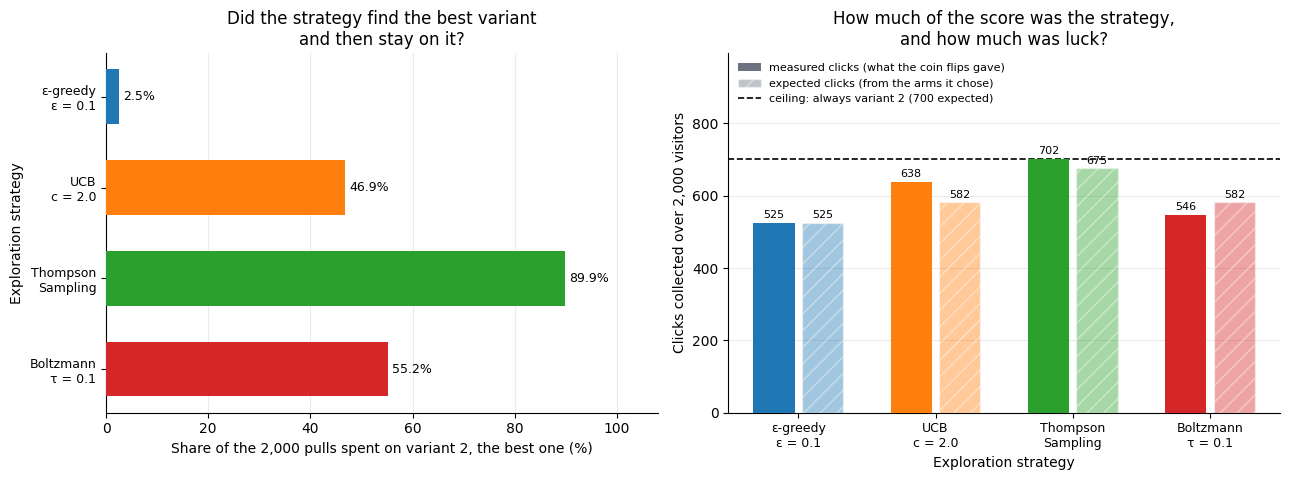

Strategy             | best-arm share |  measured |  expected |    luck
------------------------------------------------------------------------
ε-greedy (ε=0.1)     |           2.5% |       525 |     525.1 |    -0.1
UCB                  |          46.9% |       638 |     581.7 |   +56.3
Thompson Sampling    |          89.9% |       702 |     675.2 |   +26.8
Boltzmann (τ=0.1)    |          55.2% |       546 |     581.5 |   -35.5

'luck' is measured minus expected: pure coin-flip noise, not strategy quality.


In [4]:
# Closing figure: the comparison table as two charts — and the part a "total reward"
# column hides. Expected clicks come from the HIDDEN true rates of the arms each
# strategy actually chose; measured clicks are the coin flips that actually landed.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Four strategies = four categories. Categories get bars; a line between them would
# suggest something continuous runs from "UCB" to "Thompson Sampling", and nothing does.
names = list(strategies.keys())
short_names = ["ε-greedy\nε = 0.1", "UCB\nc = 2.0", "Thompson\nSampling", "Boltzmann\nτ = 0.1"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]   # same colour per strategy as the figure above

best_share = np.array([100.0 * np.mean(np.array(arms) == BEST_ARM)
                       for _, arms in strategies.values()])
measured = np.array([float(np.sum(rewards)) for rewards, _ in strategies.values()])
expected = np.array([float(np.sum([TRUE_RATES[a] for a in arms]))
                     for _, arms in strategies.values()])

fig, (ax_share, ax_luck) = plt.subplots(1, 2, figsize=(13, 4.9))

# ---------- Left: how often did each strategy actually play the best variant? ----------
y = np.arange(len(names))
bars = ax_share.barh(y, best_share, 0.6, color=colors, zorder=3)
ax_share.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
ax_share.set_yticks(y)
ax_share.set_yticklabels(short_names, fontsize=9)
ax_share.invert_yaxis()                      # keep the reading order of the table above
ax_share.set_xlabel(f"Share of the 2,000 pulls spent on variant {BEST_ARM}, the best one (%)")
ax_share.set_ylabel("Exploration strategy")
ax_share.set_title("Did the strategy find the best variant\nand then stay on it?")
ax_share.set_xlim(0, 108)
ax_share.spines[["top", "right"]].set_visible(False)
ax_share.grid(axis="x", alpha=0.25, zorder=0)

# ---------- Right: measured clicks vs the clicks those choices deserved ----------
x = np.arange(len(names))
bar_width = 0.30          # a visible gap so the two value labels never touch
b_meas = ax_luck.bar(x - bar_width / 1.7, measured, bar_width, color=colors, zorder=3)
b_exp = ax_luck.bar(x + bar_width / 1.7, expected, bar_width, color=colors, alpha=0.42,
                    hatch="//", edgecolor="white", zorder=3)
ax_luck.bar_label(b_meas, fmt="%.0f", fontsize=8, padding=2)
ax_luck.bar_label(b_exp, fmt="%.0f", fontsize=8, padding=2)

# Colour means "which strategy", so the legend explains the two SHAPES in neutral grey.
series_key = [Patch(facecolor="#6b7280", label="measured clicks (what the coin flips gave)"),
              Patch(facecolor="#6b7280", alpha=0.42, hatch="//", edgecolor="white",
                    label="expected clicks (from the arms it chose)")]

# The ceiling: always showing the best variant for all 2,000 rounds.
ax_luck.axhline(BEST_RATE * N_ROUNDS, color="black", ls="--", lw=1.2,
                label=f"ceiling: always variant {BEST_ARM} ({BEST_RATE * N_ROUNDS:.0f} expected)", zorder=2)
ax_luck.set_xticks(x)
ax_luck.set_xticklabels(short_names, fontsize=9)
ax_luck.set_xlabel("Exploration strategy")
ax_luck.set_ylabel("Clicks collected over 2,000 visitors")
ax_luck.set_title("How much of the score was the strategy,\nand how much was luck?")
ax_luck.set_ylim(0, BEST_RATE * N_ROUNDS * 1.42)
ax_luck.legend(handles=[*series_key, ax_luck.lines[0]], fontsize=8, frameon=False, loc="upper left")
ax_luck.spines[["top", "right"]].set_visible(False)
ax_luck.grid(axis="y", alpha=0.25, zorder=0)

plt.tight_layout()
plt.show()

print(f"{'Strategy':<20} | {'best-arm share':>14} | {'measured':>9} | {'expected':>9} | {'luck':>7}")
print("-" * 72)
for name, share, m, e in zip(names, best_share, measured, expected):
    print(f"{name:<20} | {share:>13.1f}% | {m:>9.0f} | {e:>9.1f} | {m - e:>+7.1f}")
print("\n'luck' is measured minus expected: pure coin-flip noise, not strategy quality.")


### 👁️ Read the figure

**Left — where the pulls went.** Share of the 2,000 pulls spent on variant 2, the only 35%
variant. Thompson Sampling **89.9%**, Boltzmann **55.2%**, UCB **46.9%**, ε-greedy **2.5%**.
ε-greedy did not merely explore too much — it locked onto the *wrong* variant and its 10%
exploration budget was spread over all five arms, so it almost never revisited the best one.

**Right — and now the warning this lesson is named after.** Solid bars are the clicks that
actually landed; hatched bars are what those same choices were *expected* to earn given the
hidden rates. Compare **UCB (638 measured, 582 expected)** with **Boltzmann (546 measured,
582 expected)**.

- Their expected totals differ by **0.2 clicks**. Their regret in the table differs by
  **0.2** (118.3 vs 118.5). By every measure of decision quality they tied.
- Their measured totals differ by **92 clicks**. All of that gap is coin flips: UCB got
  **+56** more than it deserved, Boltzmann **−36** less.

**What it proves:** on this seed a "UCB beats Boltzmann by 17%" headline would be entirely
manufactured by luck. The safe reading of the left panel and the regret curves is that
Thompson Sampling genuinely dominated here and ε-greedy genuinely failed; the middle two are
a tie that one run cannot separate. That is exactly the *safe conclusions* rule stated at the
top of this notebook — and the reason a comparison needs many seeds before it names a winner.

## ⚠️ Where this breaks

**The assumption that has to hold:** the comparison is fair, and one run of it means something. Both
halves fail more often than people expect.

- **One seed cannot rank close strategies.** The notebook states this in its own output. UCB at 638
  and Boltzmann at 546 differ by less than the run-to-run spread that lesson 05 measures for a single
  parameter. Treat any gap under a few hundred here as unresolved.
- **Regret is only computable because we know the truth.** "Final regret 24.8" is measured against the
  best arm's *true* payoff — a number that exists in this notebook and nowhere in production. Offline,
  you get regret; online, you get the reward you collected and no idea what you missed. That gap is
  what the Decision Service's logged probabilities are for.
- **Each strategy carries a hidden parameter.** ε=0.1, τ=0.1, and UCB's confidence constant were all
  chosen by somebody. The table compares four *configurations*, not four algorithms — and lesson 05
  shows that changing ε alone moves the total by more than the gap between two strategies here.
- **The metrics disagree, and that is normal.** Total reward, regret and best-arm share rank these
  four differently. Pick your metric before you run the experiment, or you will pick the one that
  flatters the answer you already like.
- **Cheaper alternative:** if you only need to know whether B beats A, and you can afford a fixed
  test period, run a randomised A/B test with a pre-registered analysis. It answers a narrower
  question with much less room to fool yourself, and it is the comparison your stakeholders already
  know how to read.


## Closing Takeaway

**Teaching takeaway:** Comparing exploration methods reveals that no single strategy is best in every setting; the environment structure matters.

**If students remember one idea:** Method comparison is meaningful only when students explain why one strategy wins under specific conditions.

**Quick check before moving on:**
- Can you explain what the comparison tells you beyond who had the highest final score?
- Can you describe an environment where one exploration method may outperform another?

**Bridge to the next step:** After comparison comes tuning: learning how to set parameters so exploration works well in practice.

Final note: treat the winner here as the winner for **this simulation**, not as a universal champion across all RL tasks.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=8 | term=True | trunc=False


objc[55549]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x10fdc0138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1102bc9c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[55549]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x10fdc0188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1102bca18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[55549]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x10fdbfc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1102bca68). T

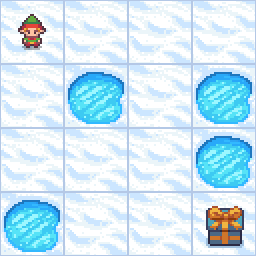

In [5]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
